In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import os

f1=pd.read_csv("C:/Users/SOWMIYA/Downloads/clinical_data_breast_cancer.csv")


In [17]:
f1

,Complete TCGA ID,Gender,Age at Initial Pathologic Diagnosis,ER Status,PR Status,HER2 Final Status,Tumor,Tumor--T1 Coded,Node,Node-Coded,...,PAM50 mRNA,SigClust Unsupervised mRNA,SigClust Intrinsic mRNA,miRNA Clusters,methylation Clusters,RPPA Clusters,CN Clusters,Integrated Clusters (with PAM50),Integrated Clusters (no exp),Integrated Clusters (unsup exp)
0,TCGA-A2-A0T2,FEMALE,66,Negative,Negative,Negative,T3,T_Other,N3,Positive,...,Basal-like,0,-13,3,5,Basal,3,2,2,2
1,TCGA-A2-A0CM,FEMALE,40,Negative,Negative,Negative,T2,T_Other,N0,Negative,...,Basal-like,-12,-13,4,4,Basal,4,2,1,1
2,TCGA-BH-A18V,FEMALE,48,Negative,Negative,Negative,T2,T_Other,N1,Positive,...,Basal-like,-12,-13,5,5,Basal,1,2,2,2
3,TCGA-BH-A18Q,FEMALE,56,Negative,Negative,Negative,T2,T_Other,N1,Positive,...,Basal-like,-12,-13,5,5,Basal,1,2,2,2
4,TCGA-BH-A0E0,FEMALE,38,Negative,Negative,Negative,T3,T_Other,N3,Positive,...,Basal-like,0,-13,5,5,Basal,1,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,TCGA-BH-A0C7,FEMALE,48,Positive,Negative,Positive,T2,T_Other,N1,Positive,...,Luminal B,-3,0,4,4,LumA/B,5,4,1,3
101,TCGA-BH-A0DD,MALE,58,Positive,Positive,Positive,T2,T_Other,N1,Positive,...,Luminal B,-3,-6,4,4,LumA/B,3,4,1,3
102,TCGA-C8-A12U,FEMALE,46,Positive,Positive,Negative,T2,T_Other,N1,Positive,...,Luminal B,-5,-2,5,4,Basal,5,4,1,1
103,TCGA-C8-A12W,FEMALE,49,Positive,Positive,Negative,T4,T_Other,N1,Positive,...,Luminal B,-5,-2,4,4,ReacII,3,4,1,1


In [18]:
f1.isnull().sum()

Complete TCGA ID                        0
Gender                                  0
Age at Initial Pathologic Diagnosis     0
ER Status                               0
PR Status                               0
HER2 Final Status                       0
Tumor                                   0
Tumor--T1 Coded                         0
Node                                    0
Node-Coded                              0
Metastasis                              0
Metastasis-Coded                        0
AJCC Stage                              0
Converted Stage                         0
Survival Data Form                      0
Vital Status                            0
Days to Date of Last Contact            0
Days to date of Death                  94
OS event                                0
OS Time                                 0
PAM50 mRNA                              0
SigClust Unsupervised mRNA              0
SigClust Intrinsic mRNA                 0
miRNA Clusters                    

In [27]:
f1.pop('Days to date of Death' )

0       240.0
1       754.0
2      1555.0
3      1692.0
4         NaN
        ...  
100       NaN
101       NaN
102       NaN
103       NaN
104       NaN
Name: Days to date of Death, Length: 105, dtype: float64

In [28]:
f1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 29 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Complete TCGA ID                     105 non-null    object
 1   Gender                               105 non-null    object
 2   Age at Initial Pathologic Diagnosis  105 non-null    int64 
 3   ER Status                            105 non-null    object
 4   PR Status                            105 non-null    object
 5   HER2 Final Status                    105 non-null    object
 6   Tumor                                105 non-null    object
 7   Tumor--T1 Coded                      105 non-null    object
 8   Node                                 105 non-null    object
 9   Node-Coded                           105 non-null    object
 10  Metastasis                           105 non-null    object
 11  Metastasis-Coded                     105 non-

In [67]:
filtered_f1=print("Details of Females with living and negative metastasis \n\n",f1[(f1['Gender']=='FEMALE') & (f1['Vital Status']=='LIVING') & (f1['Metastasis-Coded']=='Negative')])

Details of Females with living and negative metastasis 

     Complete TCGA ID  Gender  Age at Initial Pathologic Diagnosis ER Status  \
4       TCGA-BH-A0E0  FEMALE                                   38  Negative   
5       TCGA-A7-A0CE  FEMALE                                   57  Negative   
6       TCGA-D8-A142  FEMALE                                   74  Negative   
7       TCGA-A2-A0D0  FEMALE                                   60  Negative   
8       TCGA-AO-A0J6  FEMALE                                   61  Negative   
..               ...     ...                                  ...       ...   
99      TCGA-BH-A0BZ  FEMALE                                   59  Positive   
100     TCGA-BH-A0C7  FEMALE                                   48  Positive   
102     TCGA-C8-A12U  FEMALE                                   46  Positive   
103     TCGA-C8-A12W  FEMALE                                   49  Positive   
104     TCGA-E2-A15A  FEMALE                                   45  Positi

In [40]:
print(len(filtered_f1))

92


In [41]:
print(f1.dtypes)

Complete TCGA ID                       object
Gender                                 object
Age at Initial Pathologic Diagnosis     int64
ER Status                              object
PR Status                              object
HER2 Final Status                      object
Tumor                                  object
Tumor--T1 Coded                        object
Node                                   object
Node-Coded                             object
Metastasis                             object
Metastasis-Coded                       object
AJCC Stage                             object
Converted Stage                        object
Survival Data Form                     object
Vital Status                           object
Days to Date of Last Contact            int64
OS event                                int64
OS Time                                 int64
PAM50 mRNA                             object
SigClust Unsupervised mRNA              int64
SigClust Intrinsic mRNA           

In [56]:
numerical_columns=f1.select_dtypes(include=['int64']).columns
categorical_columns=f1.select_dtypes(include=['object']).columns

In [47]:
print("No of Numerical_columns:",len(numerical_columns))
print("Numerical columns:")
print(numerical_columns)

No of Numerical_columns: 12
Numerical columns:
Index(['Age at Initial Pathologic Diagnosis', 'Days to Date of Last Contact',
       'OS event', 'OS Time', 'SigClust Unsupervised mRNA',
       'SigClust Intrinsic mRNA', 'miRNA Clusters', 'methylation Clusters',
       'CN Clusters', 'Integrated Clusters (with PAM50)',
       'Integrated Clusters (no exp)', 'Integrated Clusters (unsup exp)'],
      dtype='object')


In [59]:
print("No of Categarical_columns:",len(categarical_columns))
print("Categorical columns:")
print(categorical_columns)

No of Categarical_columns: 17
Categorical columns:
Index(['Complete TCGA ID', 'Gender', 'ER Status', 'PR Status',
       'HER2 Final Status', 'Tumor', 'Tumor--T1 Coded', 'Node', 'Node-Coded',
       'Metastasis', 'Metastasis-Coded', 'AJCC Stage', 'Converted Stage',
       'Survival Data Form', 'Vital Status', 'PAM50 mRNA', 'RPPA Clusters'],
      dtype='object')


In [49]:
import matplotlib.pyplot as plt

C:\Users\SOWMIYA\AppData\Local\Schrodinger\PyMOL2\envs\sowmi\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


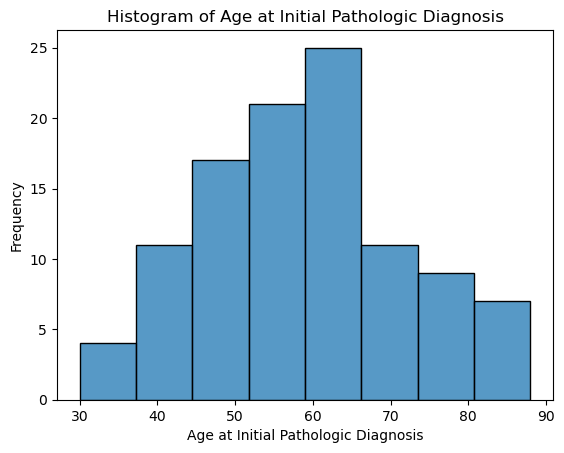

C:\Users\SOWMIYA\AppData\Local\Schrodinger\PyMOL2\envs\sowmi\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


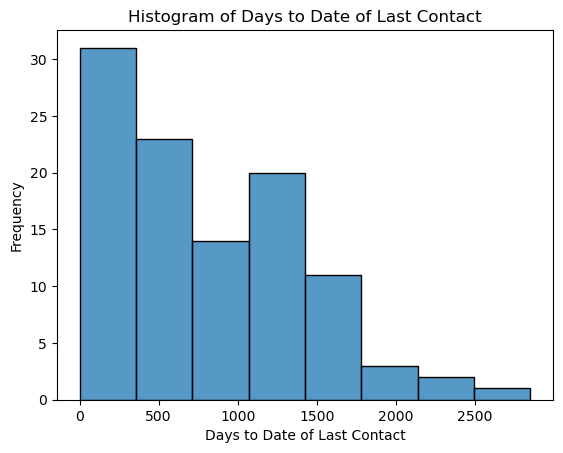

C:\Users\SOWMIYA\AppData\Local\Schrodinger\PyMOL2\envs\sowmi\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


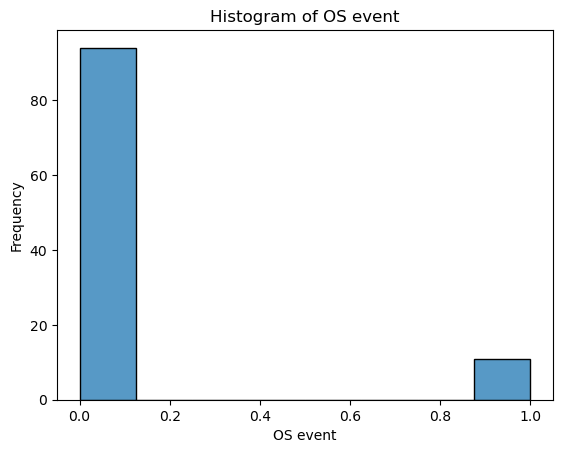

C:\Users\SOWMIYA\AppData\Local\Schrodinger\PyMOL2\envs\sowmi\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


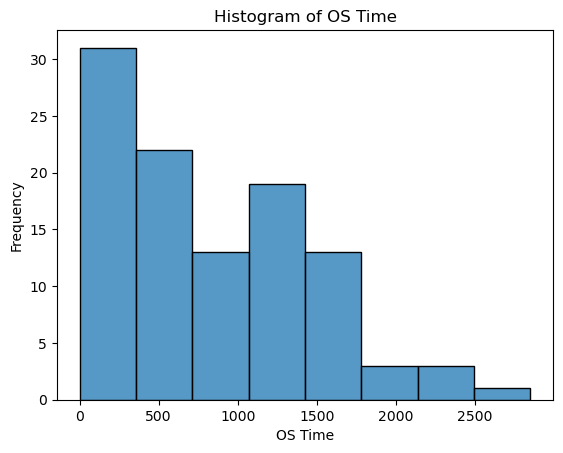

C:\Users\SOWMIYA\AppData\Local\Schrodinger\PyMOL2\envs\sowmi\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


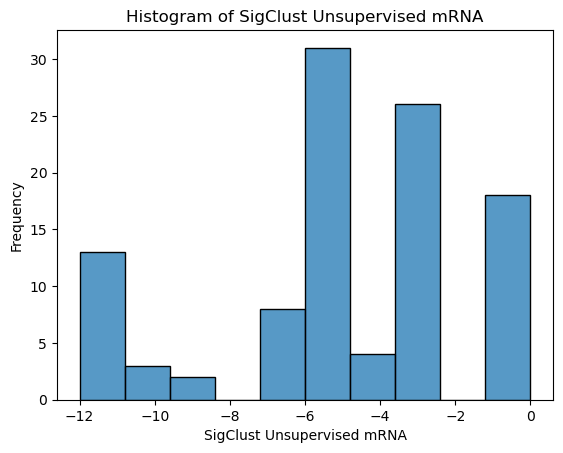

C:\Users\SOWMIYA\AppData\Local\Schrodinger\PyMOL2\envs\sowmi\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


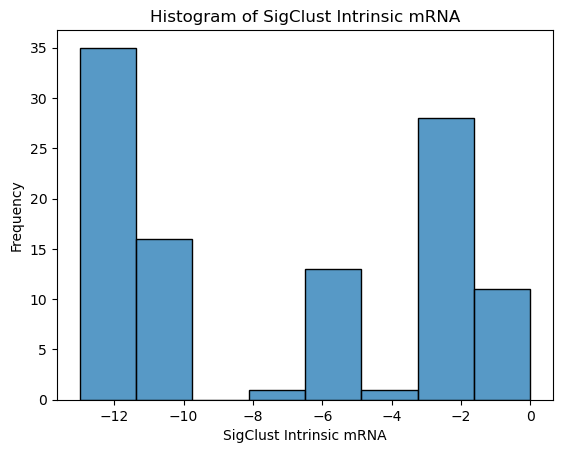

C:\Users\SOWMIYA\AppData\Local\Schrodinger\PyMOL2\envs\sowmi\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


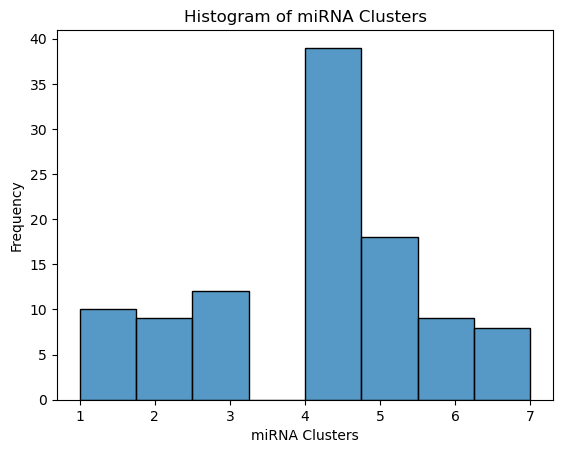

C:\Users\SOWMIYA\AppData\Local\Schrodinger\PyMOL2\envs\sowmi\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


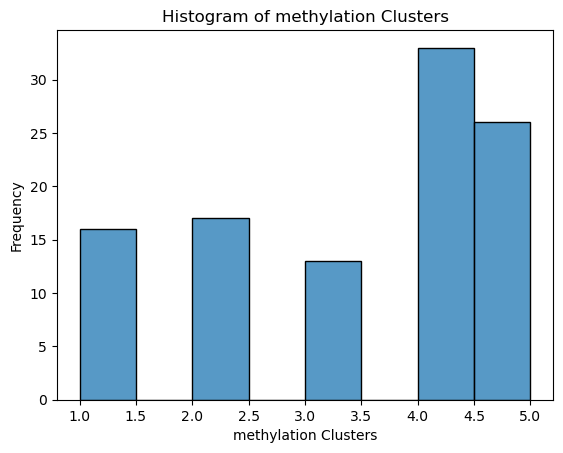

C:\Users\SOWMIYA\AppData\Local\Schrodinger\PyMOL2\envs\sowmi\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


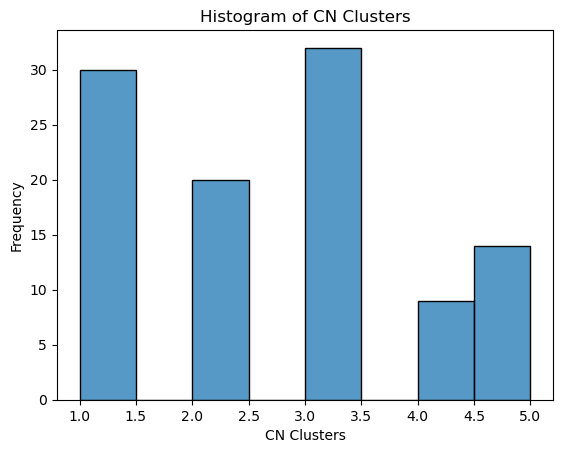

C:\Users\SOWMIYA\AppData\Local\Schrodinger\PyMOL2\envs\sowmi\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


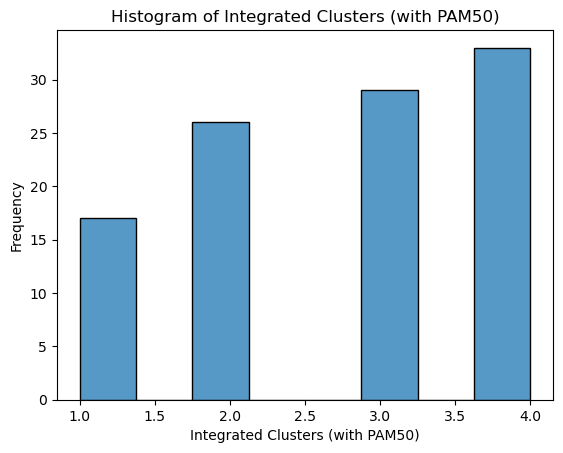

C:\Users\SOWMIYA\AppData\Local\Schrodinger\PyMOL2\envs\sowmi\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


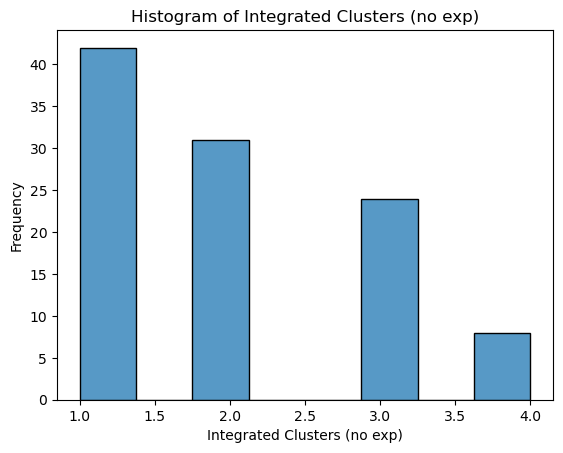

C:\Users\SOWMIYA\AppData\Local\Schrodinger\PyMOL2\envs\sowmi\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


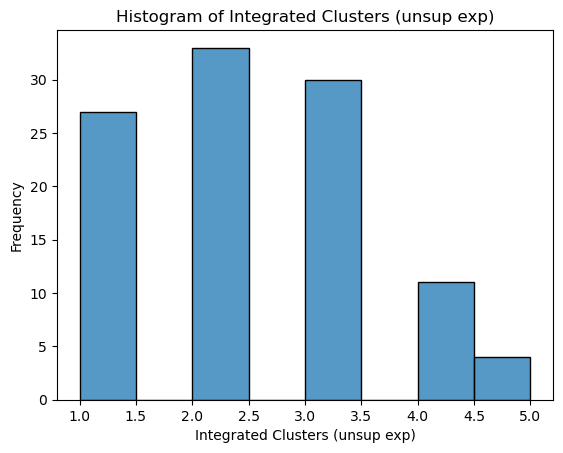

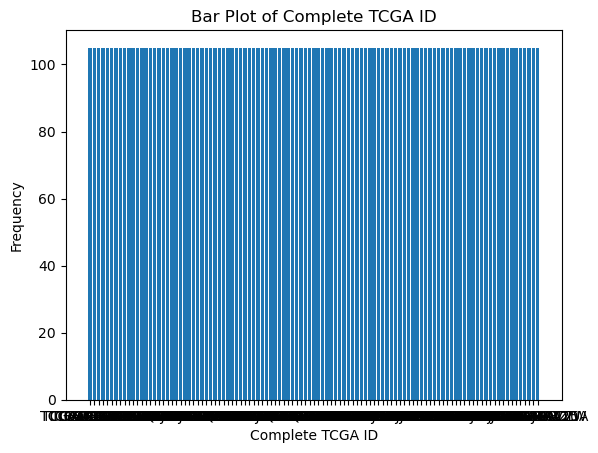

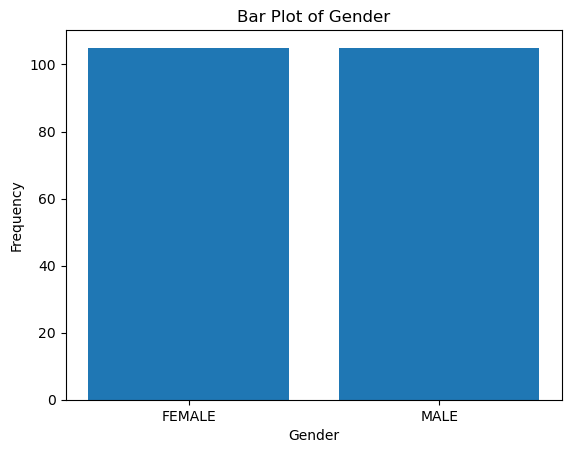

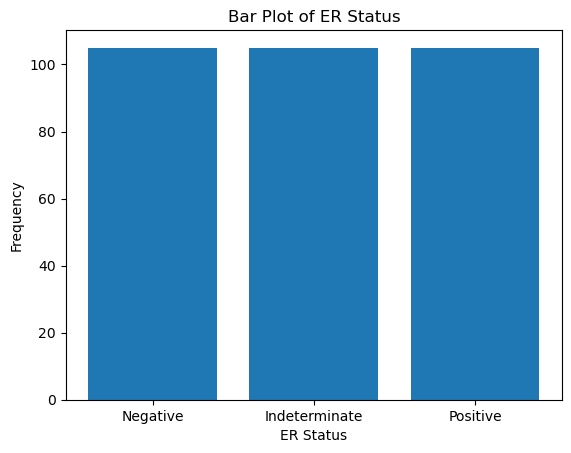

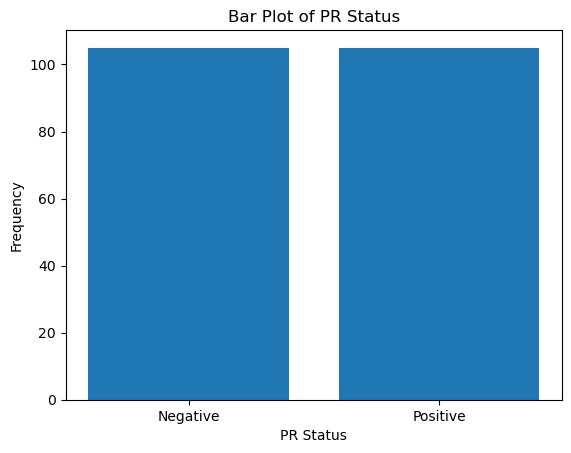

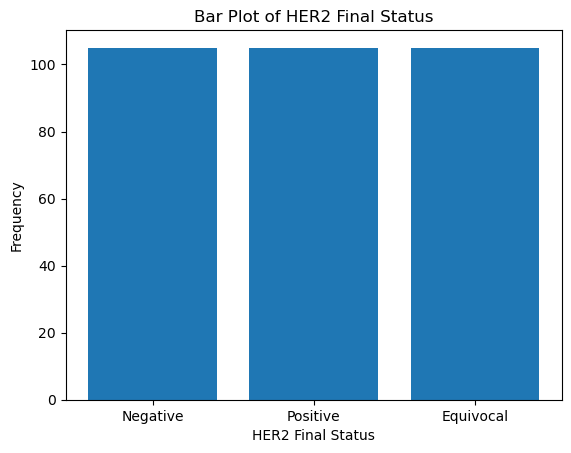

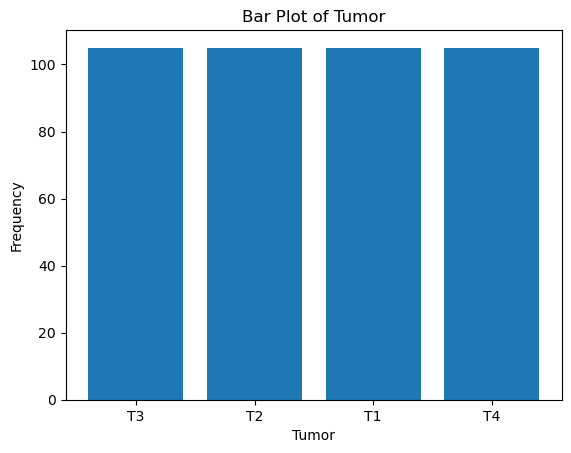

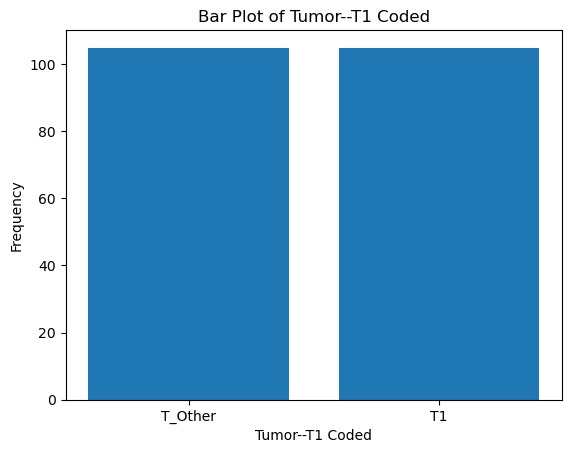

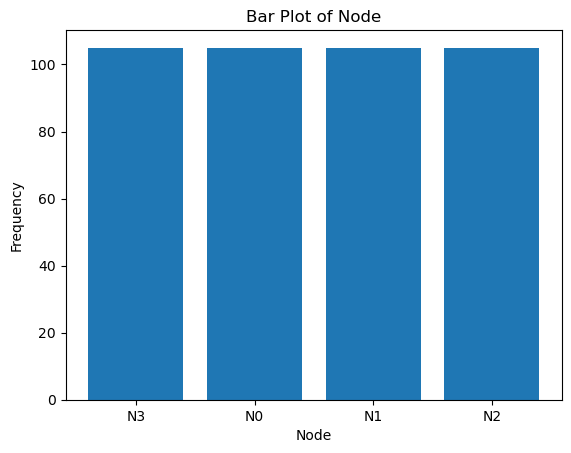

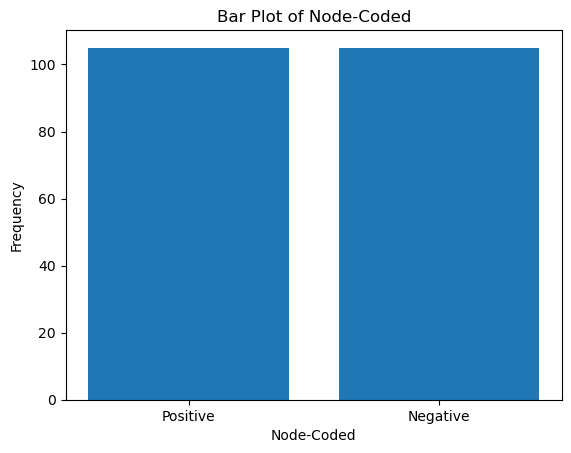

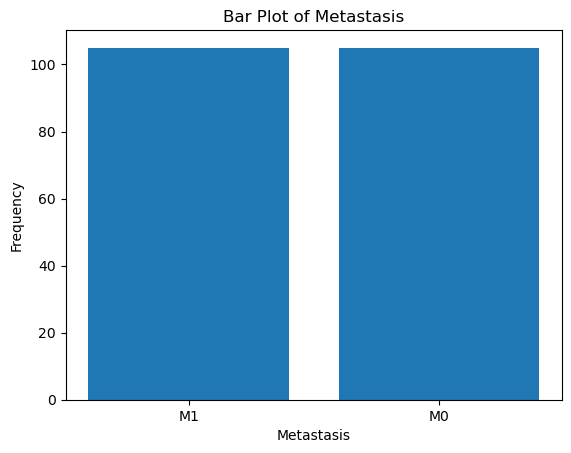

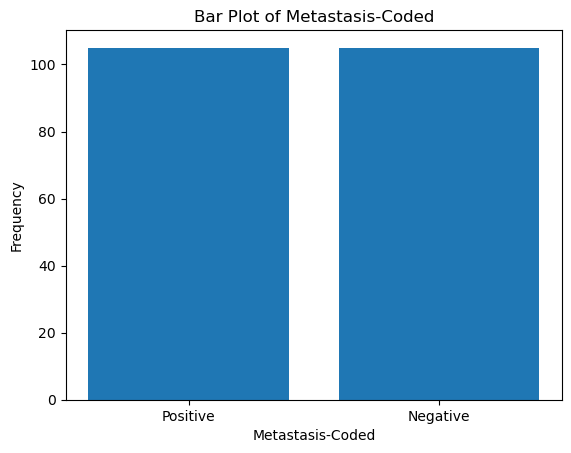

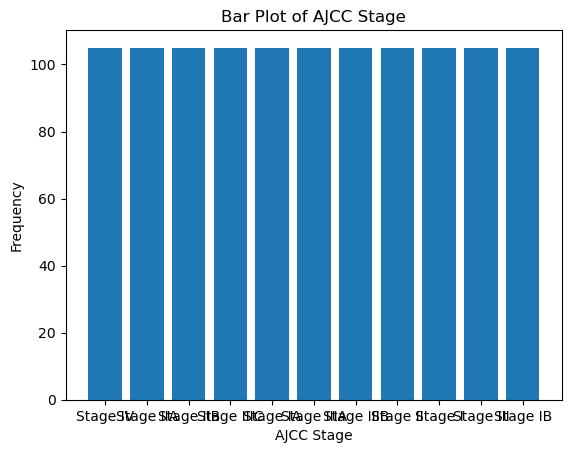

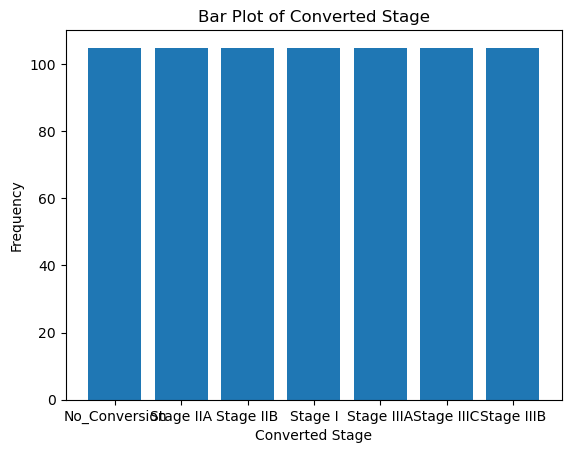

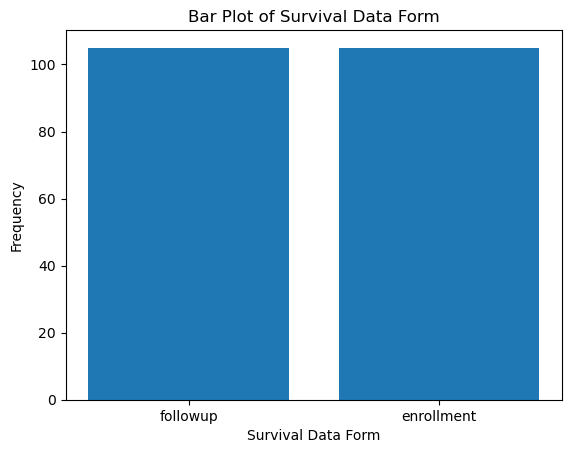

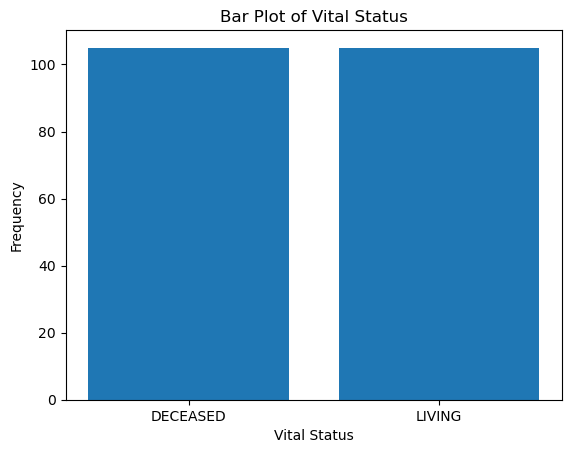

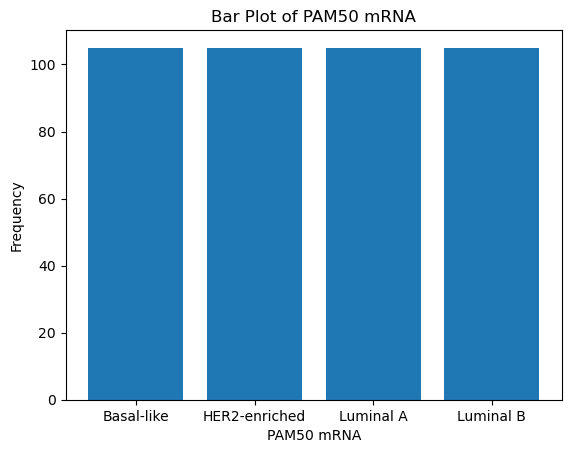

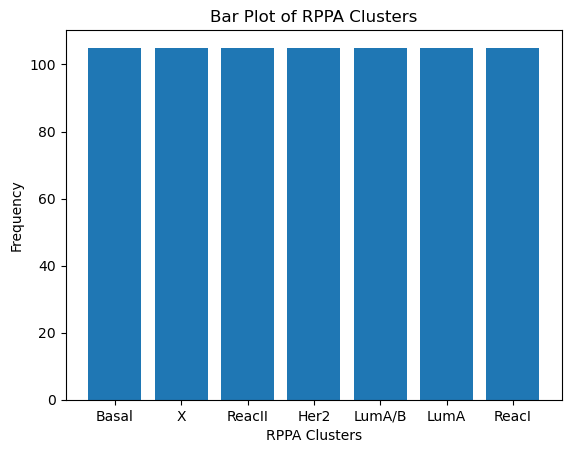

In [64]:
for distribution in numerical_columns:
    plt.figure()
    sns.histplot(f1[distribution])
    plt.title(f'Histogram of {distribution}')
    plt.xlabel(distribution)
    plt.ylabel('Frequency')
    plt.show()

for distribution in categorical_columns:
    plt.figure()
    plt.bar(f1[distribution],len(f1))
    plt.title(f'Bar Plot of {distribution}')
    plt.xlabel(distribution)
    plt.ylabel('Frequency')
    plt.show()
